In [ ]:
# Importación de librerias 
import pandas as pd 
import math 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly 
import plotly.express as px # graficos interactivos
from pathlib import Path

from plotly.subplots import make_subplots
import plotly.graph_objects as go
import math


In [2]:
# importacion de funciones 

import sys
sys.path.append(r"C:\Users\DELL\Documents\Practicas en Power BI")

from conversion_variables import convert_variables

In [3]:
path = r"C:\Users\DELL\Documents\Practicas en Power BI\Retail_SuperStore\SampleSuperstore.xlsx"  # ruta del archivo 
data = pd.read_excel(path)   # name dataframe 

In [4]:
# Primeros 10 datos de la tabla 
data.head(10) 

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.8600,7,0.00,14.1694
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,7.2800,4,0.00,1.9656
7,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Technology,Phones,907.1520,6,0.20,90.7152
8,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Binders,18.5040,3,0.20,5.7825
9,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Appliances,114.9000,5,0.00,34.4700


### Información por variable

In [5]:
info_col = []

for col in data.columns:

    nombre_col = col
    serie = data[col]

    data_type = serie.dtype

    num_values_uniques = serie.nunique()

    unique_vals = serie.dropna().unique()

    porc_nulos = serie.isnull().mean() * 100

    if len(unique_vals) > 30:
        values = list(unique_vals[:30]) + ["..."]
    else:
        values = list(unique_vals)

    info_col.append({
        "variable": nombre_col,
        "tipo de dato": str(data_type),
        "num valores únicos": num_values_uniques,
        "valores únicos (muestra)": values,
        "% valores nulos": round(porc_nulos, 2)
    })

df_info_col = pd.DataFrame(info_col)
df_info_col

,variable,tipo de dato,num valores únicos,valores únicos (muestra),% valores nulos
0,Ship Mode,str,4,"[Second Class, Standard Class, First Class, Sa...",0.0
1,Segment,str,3,"[Consumer, Corporate, Home Office]",0.0
2,Country,str,1,[United States],0.0
3,City,str,531,"[Henderson, Los Angeles, Fort Lauderdale, Conc...",0.0
4,State,str,49,"[Kentucky, California, Florida, North Carolina...",0.0
5,Postal Code,int64,631,"[42420, 90036, 33311, 90032, 28027, 98103, 761...",0.0
6,Region,str,4,"[South, West, Central, East]",0.0
7,Category,str,3,"[Furniture, Office Supplies, Technology]",0.0
8,Sub-Category,str,17,"[Bookcases, Chairs, Labels, Tables, Storage, F...",0.0
9,Sales,float64,5825,"[261.96, 731.94, 14.62, 957.5775, 22.368, 48.8...",0.0


<h3>Conversión del tipo de variables</h3>

<p>Tipos de datos soportados:</p>

<ul>
    <li><code>date</code>: Fecha</li>
    <li><code>datetime</code>: Fecha y hora</li>
    <li><code>category</code>: Variable categórica</li>
    <li><code>string</code>: Texto</li>
    <li><code>int</code>: Número entero</li>
    <li><code>float</code>: Número decimal</li>
    <li><code>bool</code>: Variable booleana</li>
</ul>

<p>
En el diccionario <code>conversiones</code> se especifican las columnas y el tipo de dato deseado.
</p>


In [66]:
# Example 
conversiones = {
    #("Order Date", "Ship Date"): "date",
    ("Category", "Region"): "category",
    "Postal Code": "category"
}
# llamada de la funcion, y actualizar en la data original 
data = convert_variables(data, conversiones) 

# corroborar que la conversion se hizo
data.info()


 La columna '('Category', 'Region')' no existe.
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Ship Mode     9994 non-null   str     
 1   Segment       9994 non-null   str     
 2   Country       9994 non-null   str     
 3   City          9994 non-null   str     
 4   State         9994 non-null   str     
 5   Postal Code   9994 non-null   category
 6   Region        9994 non-null   str     
 7   Category      9994 non-null   str     
 8   Sub-Category  9994 non-null   str     
 9   Sales         9994 non-null   float64 
 10  Quantity      9994 non-null   int64   
 11  Discount      9994 non-null   float64 
 12  Profit        9994 non-null   float64 
dtypes: category(1), float64(3), int64(1), str(8)
memory usage: 961.5 KB


### Guardar el archivo con el sufijo "_clean"

In [7]:
archivo = Path(path)

nuevo_nombre = archivo.with_name(
    archivo.stem + "_clean" + archivo.suffix
)

data.to_excel(nuevo_nombre, index=False)

print(f"Archivo guardado en:\n{nuevo_nombre}")

Archivo guardado en:
C:\Users\DELL\Documents\Practicas en Power BI\Retail_SuperStore\SampleSuperstore_clean.xlsx


### Histograma de frecuencias para variables categoricas 

In [72]:
# -----------------------------------------------------
# Seleccionar variables categóricas
# -----------------------------------------------------
categorical_cols = data.select_dtypes(
    include=["object", "category"]
).columns

# -----------------------------------------------------
# Configuración de la cuadrícula de gráficos
# -----------------------------------------------------
n_cols = 3                                    # gráficas por fila
n_rows = math.ceil(len(categorical_cols) / n_cols)

# -----------------------------------------------------
# Crear títulos incluyendo cardinalidad
# -----------------------------------------------------
subplot_titles = [
    f"{col}<br>({data[col].nunique()} valores únicos)"
    for col in categorical_cols
]

# -----------------------------------------------------
# Crear figura con subplots
# -----------------------------------------------------
fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=subplot_titles
)

# -----------------------------------------------------
# Generar una gráfica por cada variable categórica
# -----------------------------------------------------
for i, col in enumerate(categorical_cols):

    # posición dentro de la cuadrícula
    row = i // n_cols + 1
    col_pos = i % n_cols + 1

    # frecuencia de cada categoría
    counts = (
        data[col]
        .value_counts(dropna=False)
        .sort_values(ascending=False)
    )

    # gráfico de barras interactivo
    fig.add_trace(
        go.Bar(
            x=counts.index.astype(str),
            y=counts.values,
            name=col,

            # información mostrada al pasar el cursor
            hovertemplate=
            "<b>Categoría:</b> %{x}<br>" +
            "<b>Frecuencia:</b> %{y}<br>" +
            f"<b>Valores únicos:</b> {data[col].nunique()}" +
            "<extra></extra>"
        ),
        row=row,
        col=col_pos
    )

# -----------------------------------------------------
# Configuración general
# -----------------------------------------------------
fig.update_layout(
    title="Distribución de variables categóricas",
    showlegend=False,

    # aumentar tamaño para variables con muchas categorías
    height=500 * n_rows,
    width=1200,

    template="plotly_white"
)

# -----------------------------------------------------
# Configuración de todos los ejes X
# -----------------------------------------------------
fig.update_xaxes(
    tickangle=90
)

# -----------------------------------------------------
# Configuración de todos los ejes Y
# -----------------------------------------------------
fig.update_yaxes(
    title_text="Frecuencia"
)

# -----------------------------------------------------
# Mostrar figura
# -----------------------------------------------------
fig.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_28984\905018406.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(


### Histograma de frecuencias para variables categoricas 

C:\Users\DELL\AppData\Local\Temp\ipykernel_28984\2615237784.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=['object', 'category']).columns


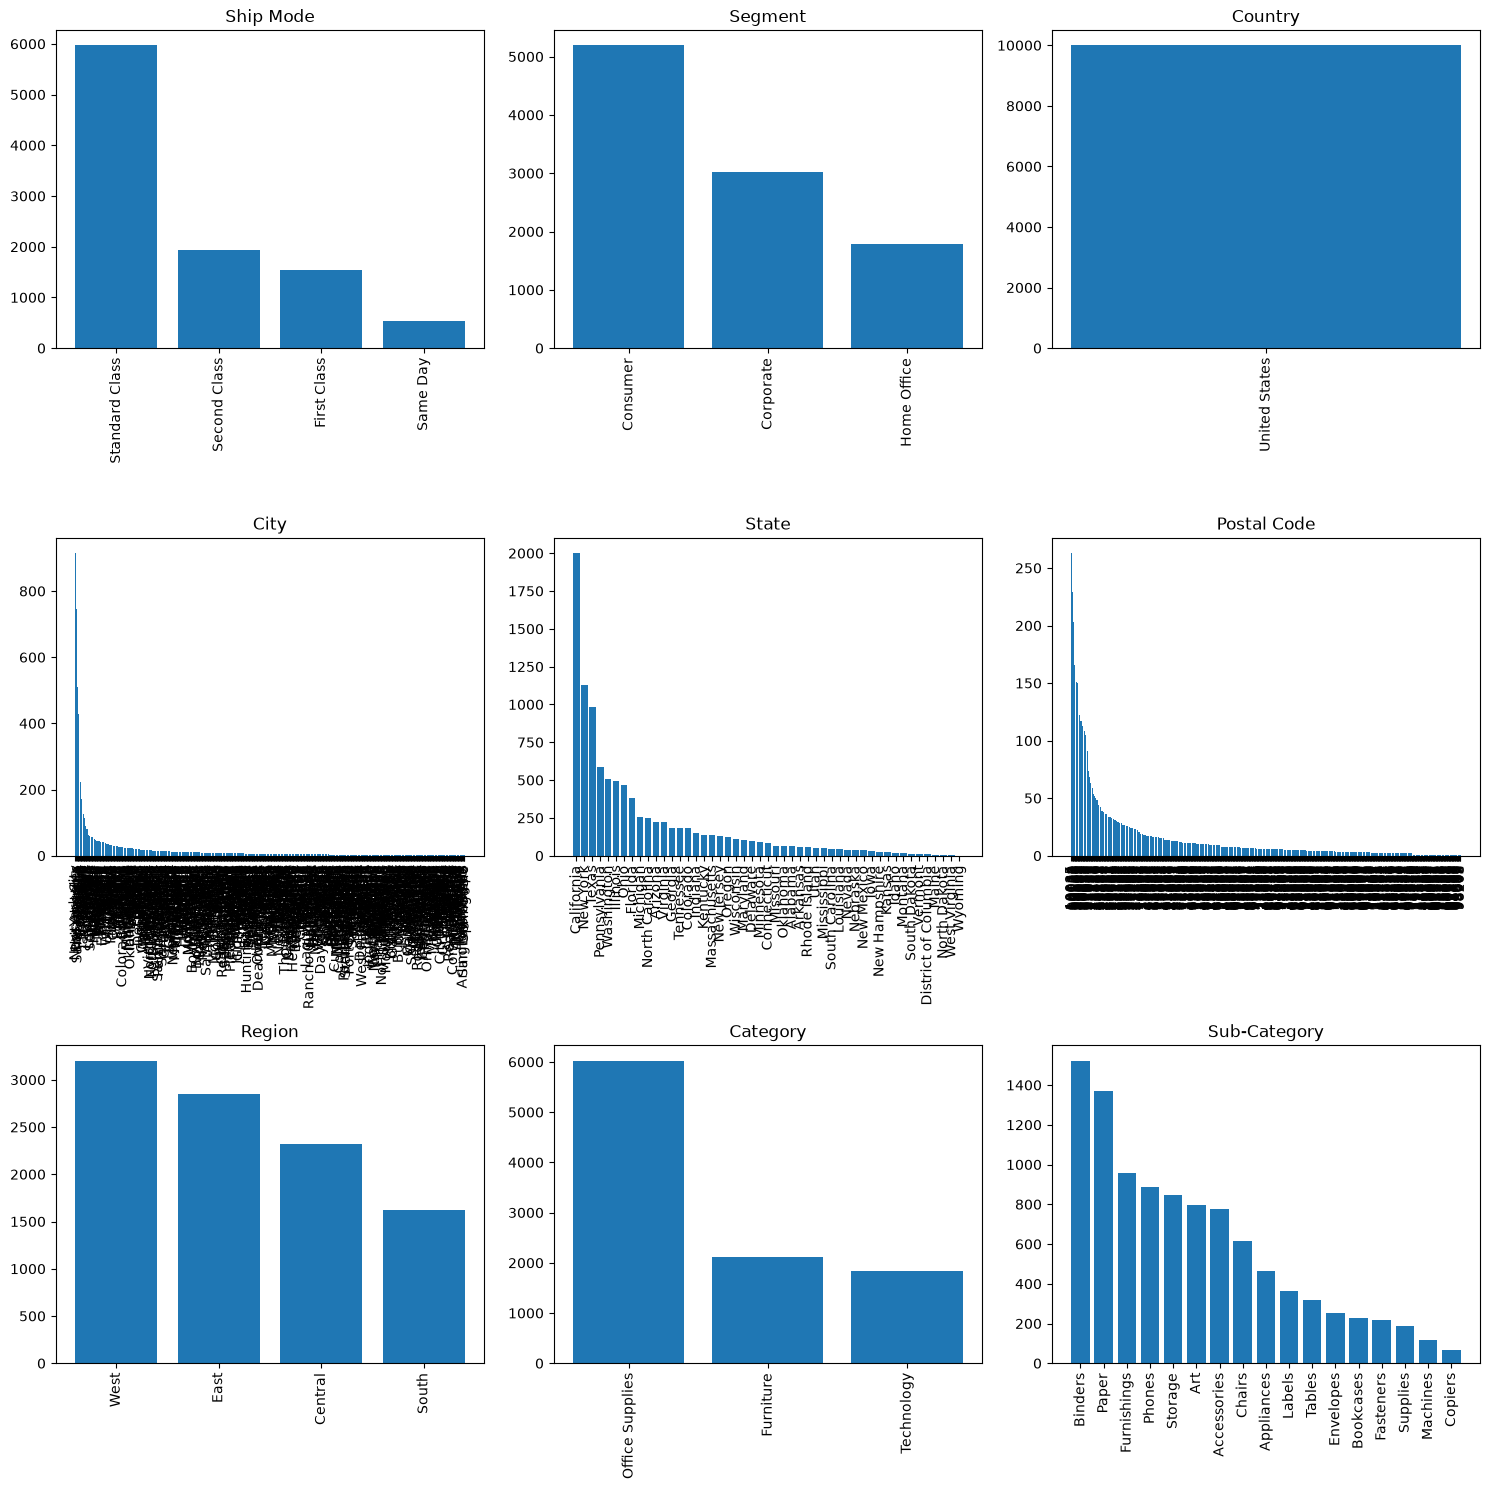

In [ ]:
# categorical_cols = data.select_dtypes(include=['object', 'category']).columns

# n_cols = 3 # numero de graficas mostradas en columnas 
# n_rows = math.ceil(len(categorical_cols)/n_cols)  # numero de graficas mostradas en filas 

# fig, axes = plt.subplots(
#     n_rows,
#     n_cols,
#     figsize=(15, 5*n_rows)
# )

# axes = axes.flatten()

# for i, col in enumerate(categorical_cols):

#     counts = data[col].value_counts()

#     axes[i].bar(
#         counts.index.astype(str),
#         counts.values
#     )

#     axes[i].set_title(col)

#     axes[i].tick_params(
#         axis='x',
#         rotation=90
#     )
# # eliminar ejes vacios
# for j in range(i+1, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()

### Gráfico de pastel de frecuencia (variables con alta cardinalidad)  (Usar Treemap en PowerBi)

Para mejorar la interpretabilidad de variables categóricas con alta cardinalidad, se utiliza una estrategia de reducción:

- Se consideran únicamente los **10 valores más frecuentes (Top 10)**.
- El resto de las categorías se agrupan en una categoría adicional denominada **"Other"**.


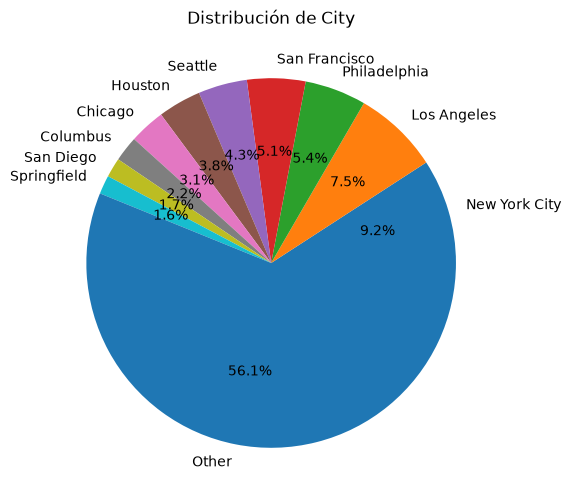

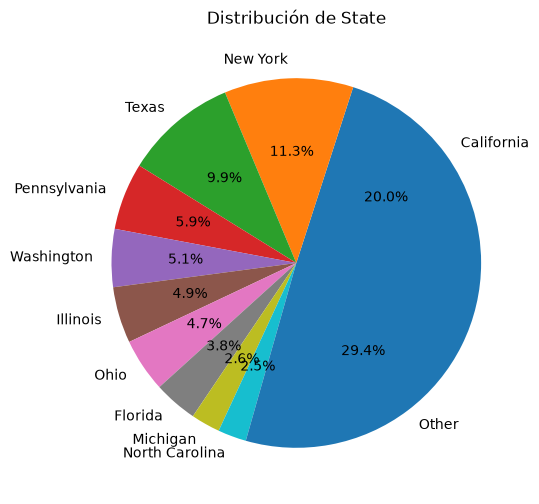

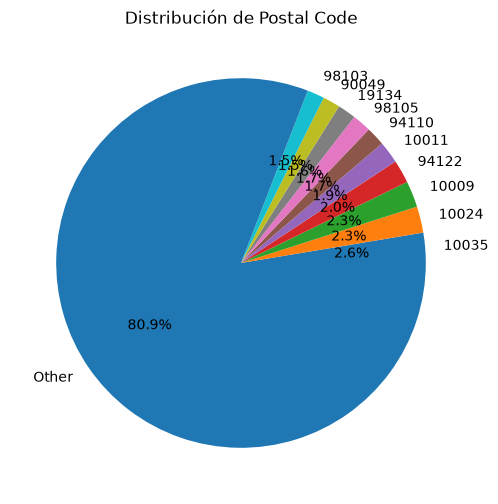

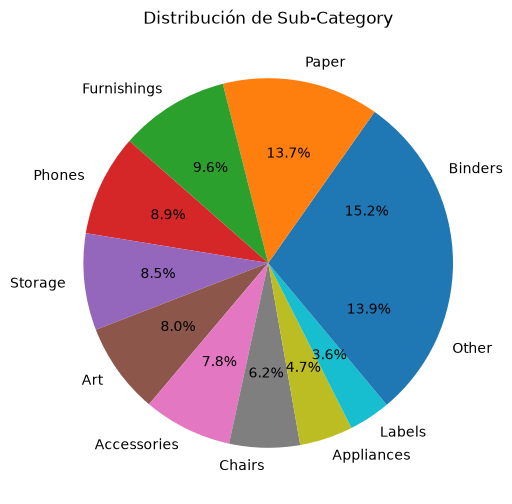

In [ ]:
def top_n_series(series, n=10):
    
    counts = series.value_counts()
    
    if len(counts) > n:
        top = counts.iloc[:n]
        others = counts.iloc[n:].sum()
        top["Other"] = others
        return top
    
    return counts

for col in categorical_cols:
    serie = data[col]
    num_values_uniques = serie.nunique()

    if (num_values_uniques > 10):
        counts = top_n_series(data[col], n=10)

        plt.figure(figsize=(6,6))
        plt.pie(
            counts.values,
            labels=counts.index,
            autopct="%1.1f%%"
        )
        plt.title(f"Distribución de {col}")
        plt.show()

### Histograma de frecuencias para variables continuas

In [ ]:
numeric_cols = data.select_dtypes(
    include=['int64','float64']
).columns

n_cols = 2
n_rows = math.ceil(len(numeric_cols)/n_cols)


fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=numeric_cols
)

for i, col in enumerate(numeric_cols):

    row = i // n_cols + 1
    col_pos = i % n_cols + 1

    fig.add_trace(
        go.Histogram(
            x=data[col],
            nbinsx=50,
            name=col
        ),
        row=row,
        col=col_pos
    )

fig.update_layout(
    height=350*n_rows,
    width=1200,
    showlegend=False,
    title="Distribuciones numéricas"
)

fig.update_yaxes(title_text="Frecuencia")

fig.show()

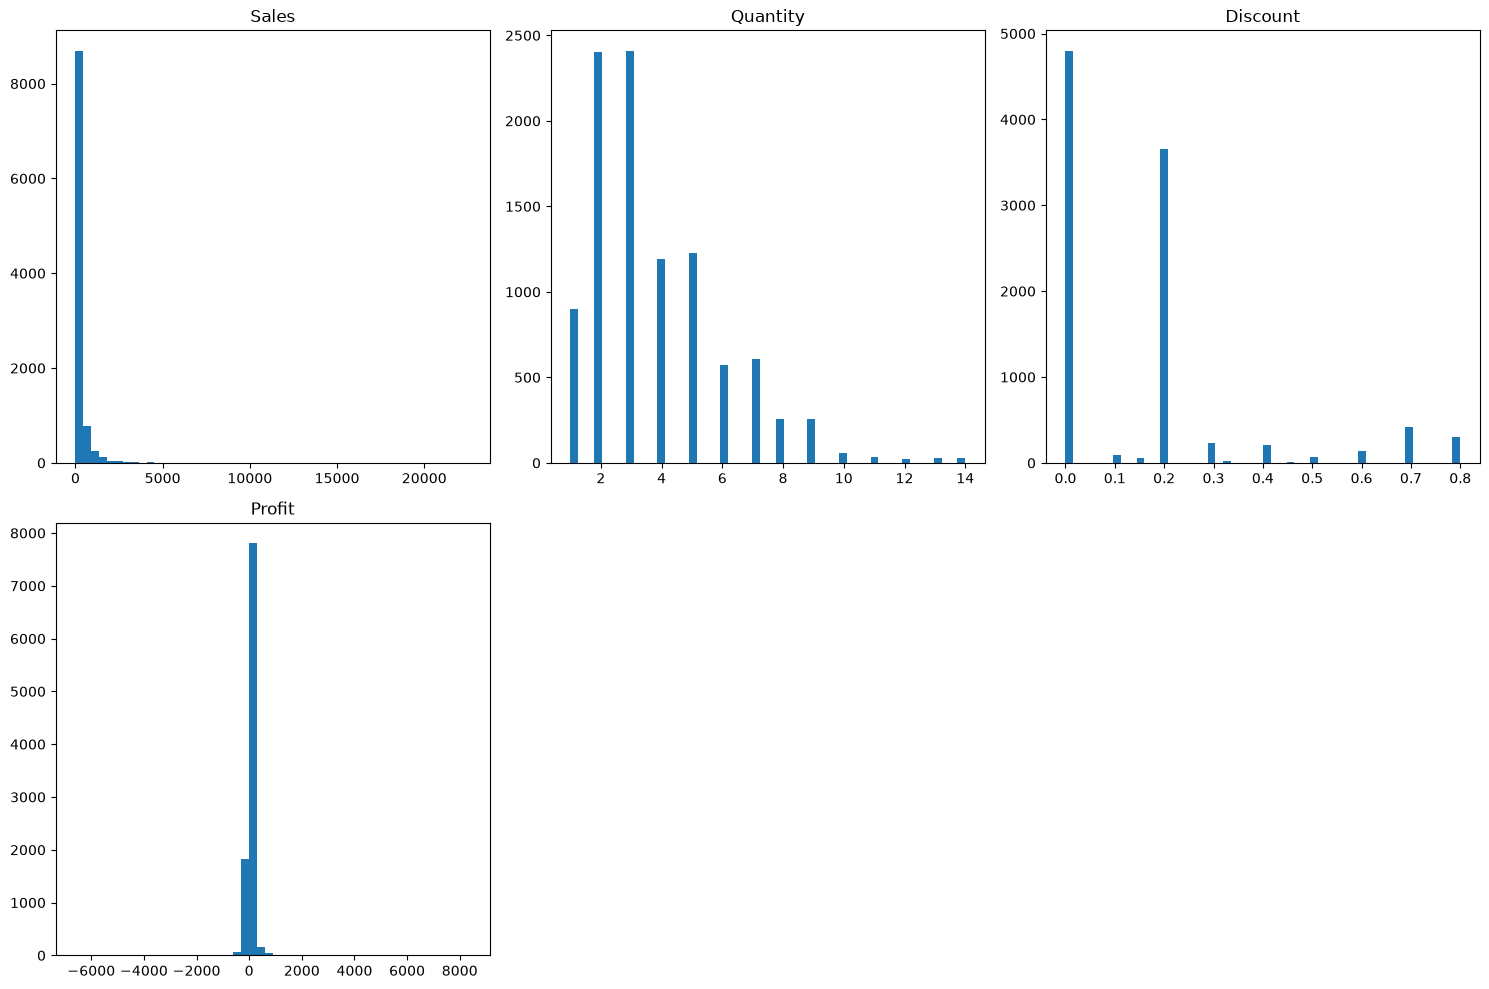

In [ ]:
# numeric_cols = data.select_dtypes(
#     include=['int64','float64']
# ).columns

# n_cols = 3
# n_rows = math.ceil(len(numeric_cols)/n_cols)

# fig, axes = plt.subplots(
#     n_rows,
#     n_cols,
#     figsize=(15, 5*n_rows)
# )

# axes = axes.flatten()

# # graficar 
# for i, col in enumerate(numeric_cols):
    
#     axes[i].hist(
#         data[col].dropna(),
#         bins=50
#     )

#     axes[i].set_title(col)
# # eliminar vacíos 
# for j in range(i+1, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()

### Observaciones duplicadas

In [11]:
duplicados = data[data.duplicated(keep=False)]

duplicados.sort_values(
    by=list(data.columns)
)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
6409,First Class,Consumer,United States,Houston,Texas,77041,Central,Office Supplies,Paper,47.952,3,0.2,16.1838
8032,First Class,Consumer,United States,Houston,Texas,77041,Central,Office Supplies,Paper,47.952,3,0.2,16.1838
5493,Same Day,Home Office,United States,San Francisco,California,94122,West,Office Supplies,Labels,41.400,4,0.0,19.8720
5905,Same Day,Home Office,United States,San Francisco,California,94122,West,Office Supplies,Labels,41.400,4,0.0,19.8720
2807,Second Class,Consumer,United States,Seattle,Washington,98115,West,Office Supplies,Paper,12.960,2,0.0,6.2208
8095,Second Class,Consumer,United States,Seattle,Washington,98115,West,Office Supplies,Paper,12.960,2,0.0,6.2208
8457,Second Class,Corporate,United States,Chicago,Illinois,60653,Central,Office Supplies,Binders,3.564,3,0.8,-6.2370
9477,Second Class,Corporate,United States,Chicago,Illinois,60653,Central,Office Supplies,Binders,3.564,3,0.8,-6.2370
8533,Standard Class,Consumer,United States,Detroit,Michigan,48227,Central,Furniture,Chairs,389.970,3,0.0,35.0973
9262,Standard Class,Consumer,United States,Detroit,Michigan,48227,Central,Furniture,Chairs,389.970,3,0.0,35.0973


In [12]:
# Agrupamos por todas las columnas del DataFrame.
# Cada grupo contendrá observaciones idénticas.
grupos = data.groupby(list(data.columns)).apply(lambda x: list(x.index))

# Nos quedamos únicamente con los grupos que aparecen
# más de una vez (duplicados)
grupos_dup = grupos[grupos.apply(len) > 1]

# Lista donde almacenaremos la información
info_duplicados = []

# Recorremos cada grupo duplicado
for indices in grupos_dup:

    # Número de observaciones en el grupo
    tam_grupo = len(indices)

    info_duplicados.append({
        "Tamaño grupo": tam_grupo,
        "Indices observaciones": tuple(indices)
    })

# Convertimos la lista de diccionarios a DataFrame
info_duplicados = pd.DataFrame(info_duplicados)

# Resumen por tamaño de grupo
info_duplicados = (
    info_duplicados
    .groupby("Tamaño grupo")
    .agg(
        frecuencia=("Tamaño grupo", "count"),
        indices_observaciones=("Indices observaciones", list)
    )
    .reset_index()
)

info_duplicados

,Tamaño grupo,frecuencia,indices_observaciones
0,2,17,"[(6409, 8032), (5493, 5905), (2807, 8095), (84..."


### Reporte de MISSING, por columna
- valores nulos (Nan, None)
- vacios " "

In [ ]:
def missing_report(df):

    nulos = df.isnull().sum()

    vacios = (
        df.select_dtypes(include=["object", "string"])
          .apply(lambda x: x.str.strip().eq("").sum())
    )

    reporte = pd.DataFrame({
        "NaN": nulos,
        "Vacios": vacios
    }).fillna(0)

    reporte["Total"] = reporte["NaN"] + reporte["Vacios"]

    reporte["% Missing"] = (
        reporte["Total"] / len(df) * 100
    ).round(2)

    return reporte

missing_report(data)

,NaN,Vacios,Total,% Missing
Category,0,0.0,0.0,0.0
City,0,0.0,0.0,0.0
Country,0,0.0,0.0,0.0
Discount,0,0.0,0.0,0.0
Postal Code,0,0.0,0.0,0.0
Profit,0,0.0,0.0,0.0
Quantity,0,0.0,0.0,0.0
Region,0,0.0,0.0,0.0
Sales,0,0.0,0.0,0.0
Segment,0,0.0,0.0,0.0


### Resumen estadístico de variables numéricas

In [35]:
data[numeric_cols].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


### Outliers 
- Con grafica de bigotes:
- percentil 25 (1er cuartil), que es el valor para el cual el 25% de los datos se encuentra por debajo de dicho valor
- percentil 50 (2do cuartil o mediana), que valor que parte el set de datos en 2 mitades (50% por encima de este valor, 50% por debajo de este valor)
- Percentil 75 (3er cuartil), que es el valor para el cual el 75% de los datos se encuentra por debajo de dicho valor

In [77]:
fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=numeric_cols
)

for i, col in enumerate(numeric_cols):

    row = i // n_cols + 1
    col_pos = i % n_cols + 1

    fig.add_trace(
        go.Box(
            y=data[col],
            boxpoints="all",
            name=col
        ),
        row=row,
        col=col_pos
    )

fig.update_layout(
    height=600*n_rows,
    width=1200,
    showlegend=False,
    title="Boxplots variables numéricas"
)

fig.show()

### Correlaciones lineales 

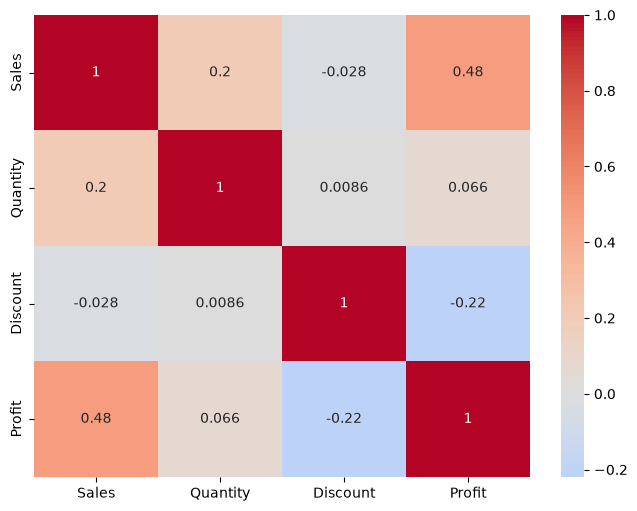

In [81]:
correlaciones= data[numeric_cols].corr()
correlaciones
plt.figure(figsize=(8,6))
sns.heatmap(correlaciones, annot=True, cmap="coolwarm", center=0)
plt.show()

Pairplot por: Category
Pairplot por: Sub-Category
Pairplot por: Region
Pairplot por: Ship Mode


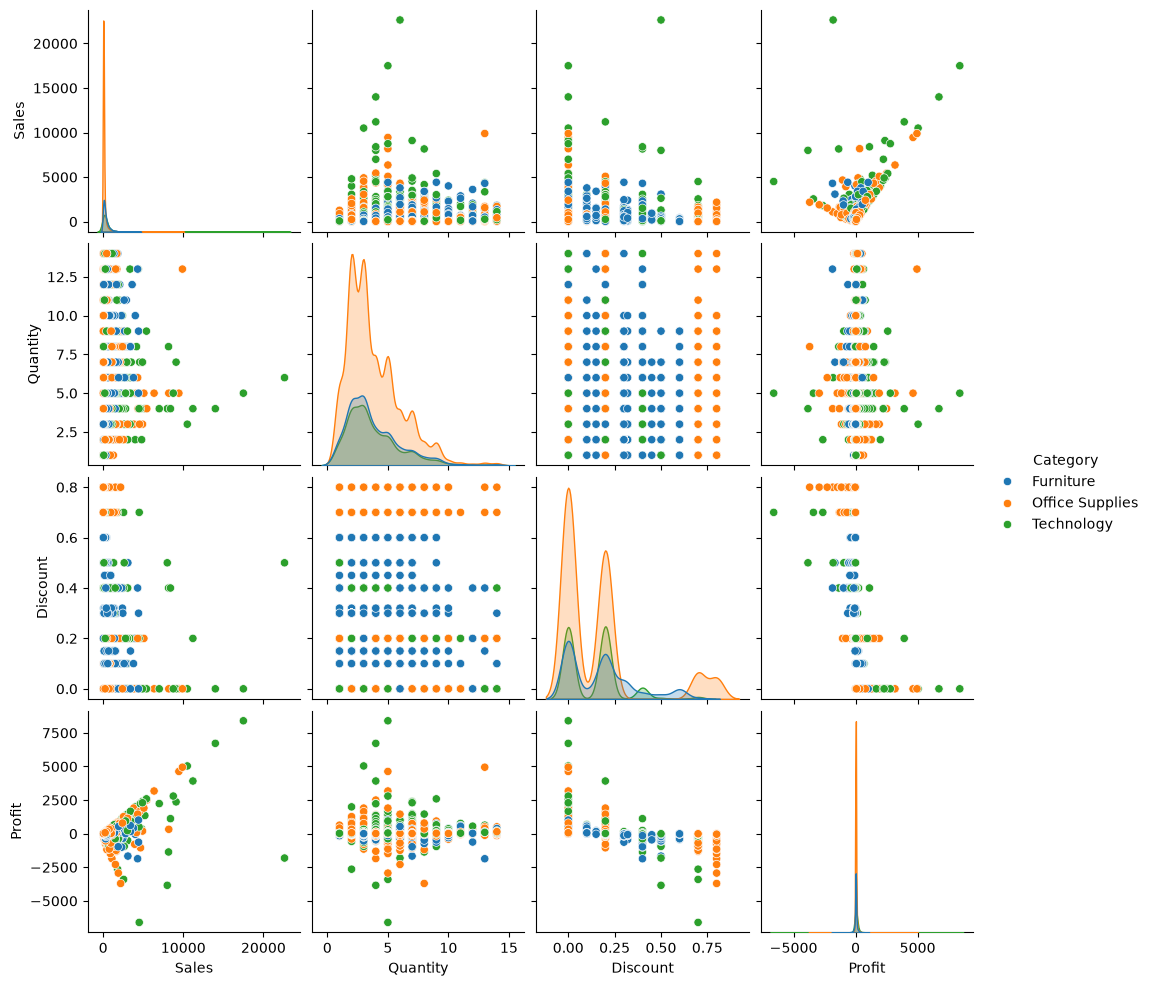

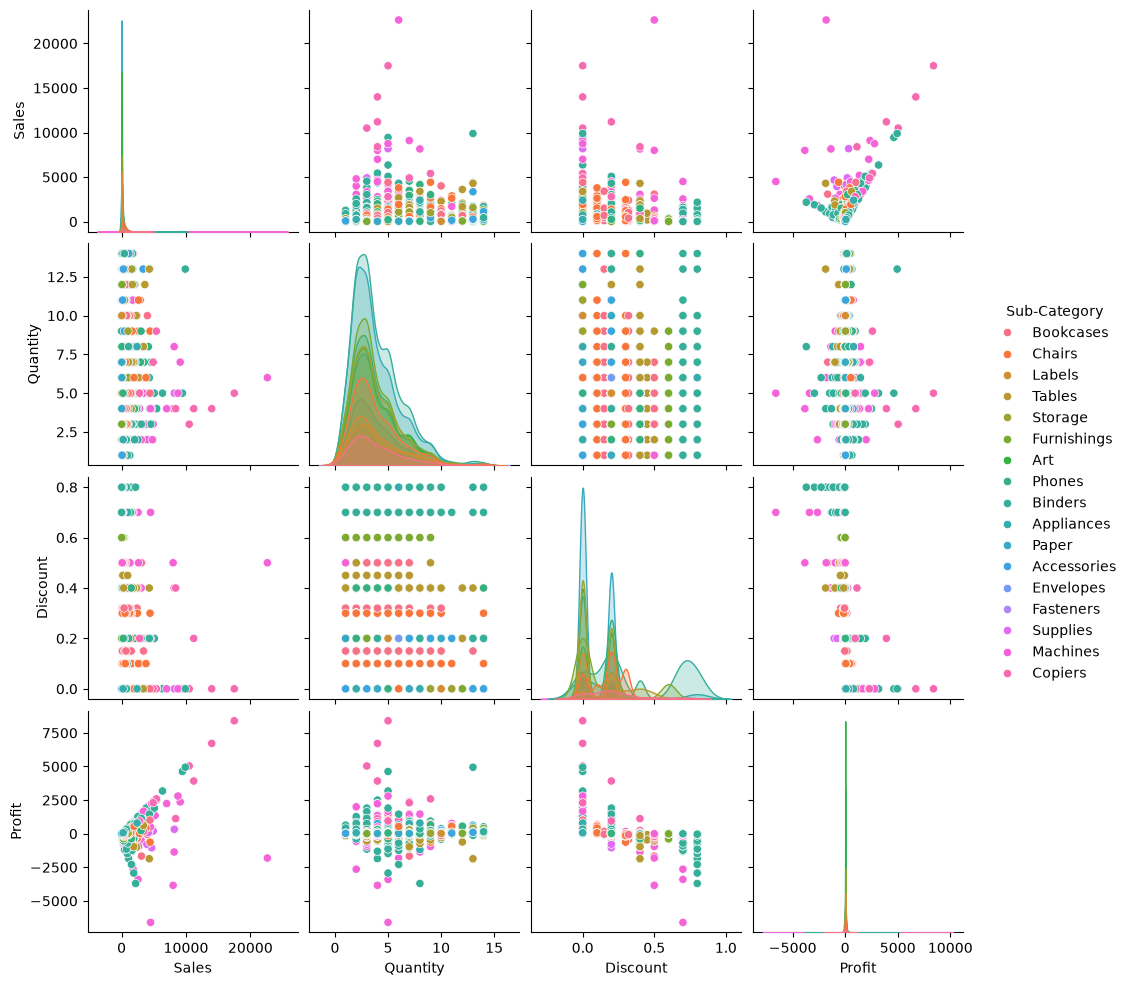

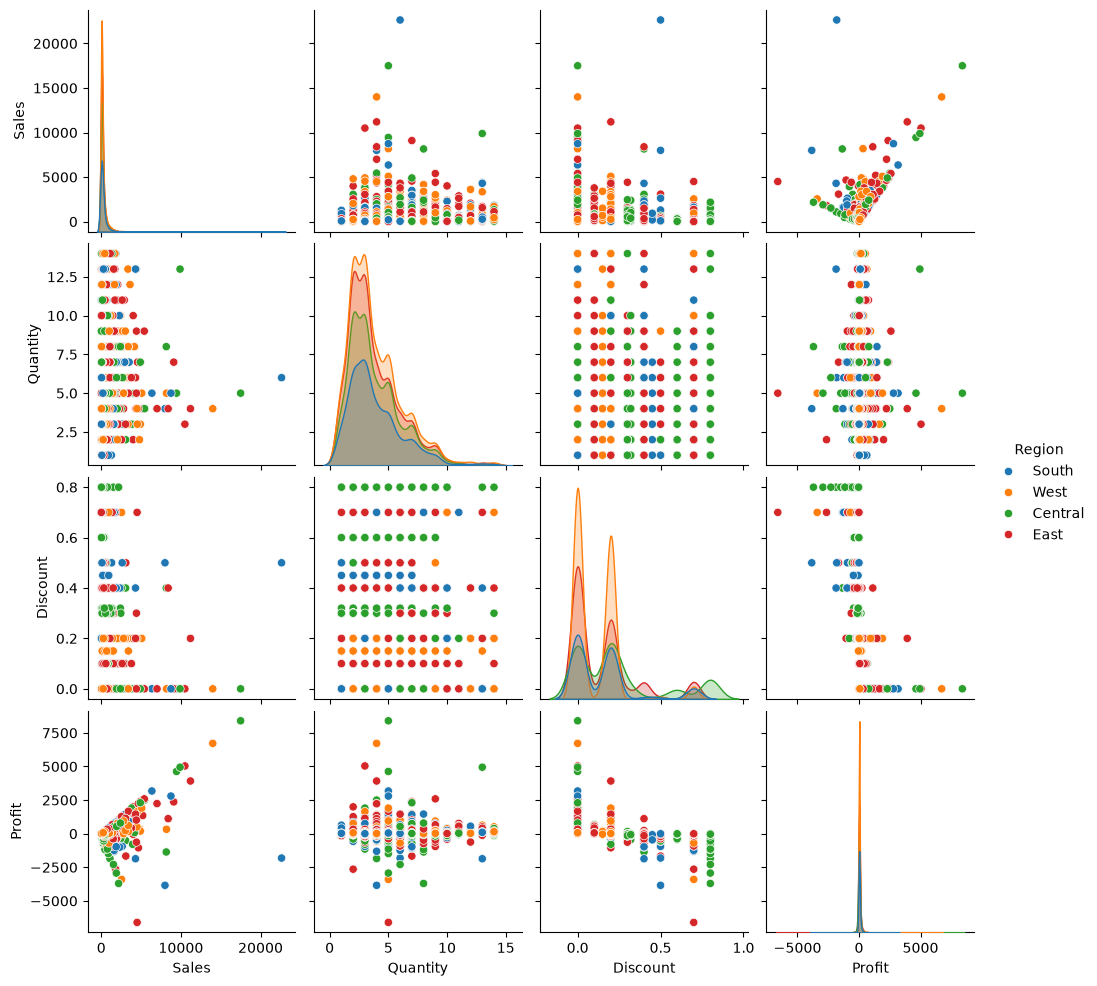

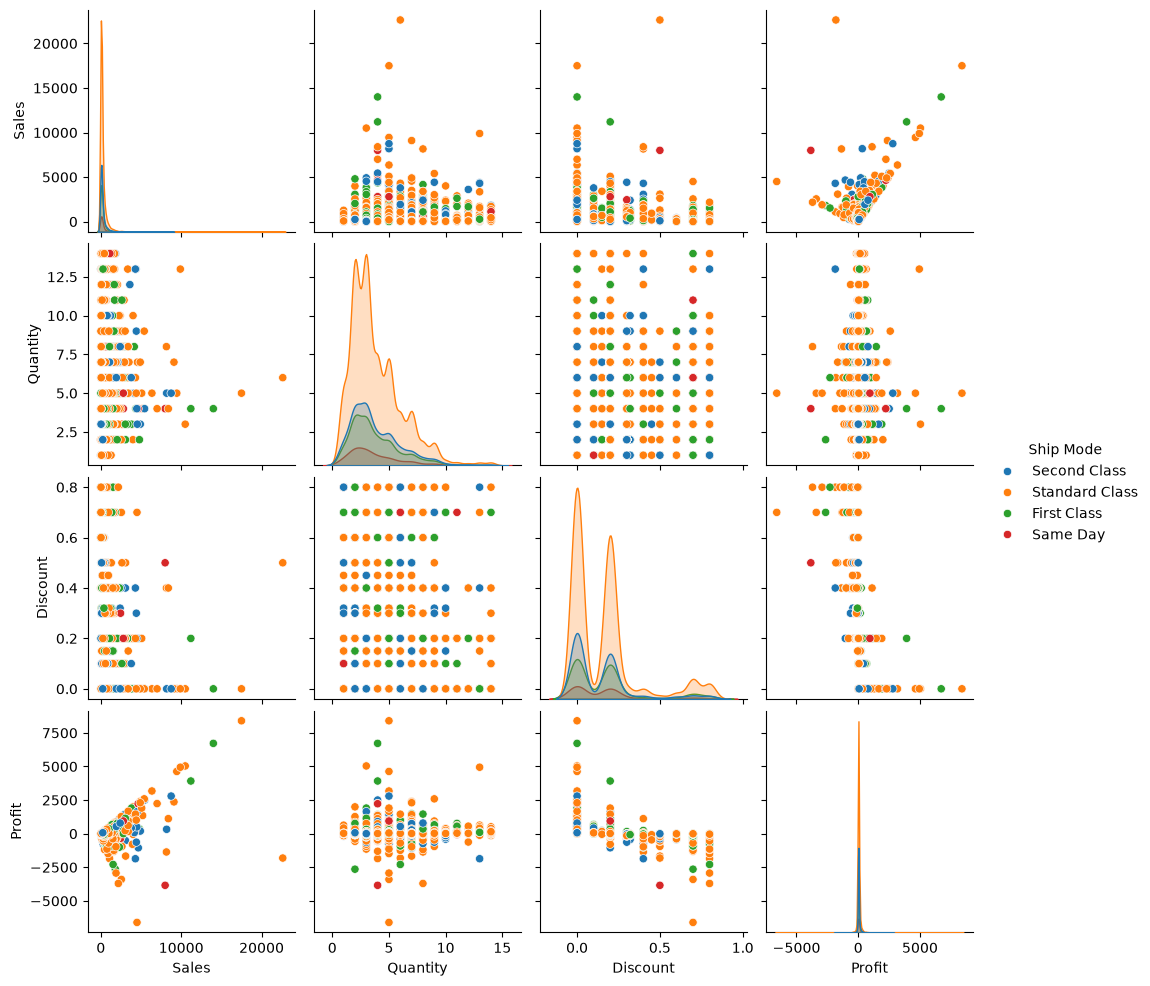

In [87]:
categorical_vars = ["Category", "Sub-Category", "Region", "Ship Mode"]

cols_numeric = data.select_dtypes(include="number").columns

for cat in categorical_vars:

    print(f"Pairplot por: {cat}")

    sns.pairplot(
        data[cols_numeric.tolist() + [cat]],
        hue=cat
    )

In [92]:
fig = px.scatter(
    data,
    x="Discount",
    y="Profit",
    color="Category",
    opacity=0.5
)

fig.show()

In [95]:
data.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [96]:
product_profitability = (
    data.groupby("Sub-Category")[["Sales","Profit"]]
        .sum()
)

product_profitability["Profit Margin"] = (
    product_profitability["Profit"] /
    product_profitability["Sales"]
)

product_profitability.sort_values(
    "Profit Margin",
    ascending=False
)

,Sales,Profit,Profit Margin
Sub-Category,,,
Labels,12486.3120,5546.2540,0.444187
Paper,78479.2060,34053.5693,0.433918
Envelopes,16476.4020,6964.1767,0.422676
Copiers,149528.0300,55617.8249,0.371956
Fasteners,3024.2800,949.5182,0.313965
Accessories,167380.3180,41936.6357,0.250547
Art,27118.7920,6527.7870,0.240711
Appliances,107532.1610,18138.0054,0.168675
Binders,203412.7330,30221.7633,0.148574


In [166]:
product_profitability = (
    data.groupby("Sub-Category", "Discount")[["Sales","Profit"]]
        .sum()
)

product_profitability["Profit Margin"] = (
    product_profitability["Profit"] /
    product_profitability["Sales"]
)

product_profitability.sort_values(
    "Profit Margin",
    ascending=False
)

ValueError: level name Discount is not the name of the index

In [97]:
product_analysis = (
    data.groupby("Sub-Category")
        .agg({
            "Sales":"sum",
            "Profit":"sum",
            "Quantity":"sum"
        })
)

product_analysis["Profit Margin"] = (
    product_analysis["Profit"] /
    product_analysis["Sales"]
)

product_analysis.sort_values(
    "Profit",
    ascending=False
)

,Sales,Profit,Quantity,Profit Margin
Sub-Category,,,,
Copiers,149528.0300,55617.8249,234,0.371956
Phones,330007.0540,44515.7306,3289,0.134893
Accessories,167380.3180,41936.6357,2976,0.250547
Paper,78479.2060,34053.5693,5178,0.433918
Binders,203412.7330,30221.7633,5974,0.148574
Chairs,328449.1030,26590.1663,2356,0.080957
Storage,223843.6080,21278.8264,3158,0.095061
Appliances,107532.1610,18138.0054,1729,0.168675
Furnishings,91705.1640,13059.1436,3563,0.142404


Agrupar por descuento:

Discount
↓

Sales promedio
Profit promedio
Profit Margin promedio
Número de ventas

Paso 2. Graficar.

Discount

vs

Average Sales

Discount

vs

Average Profit

Discount

vs

Average Profit Margin

Paso 3

Ahora sí.

Scatter.

Pero no de todas las ventas.

Sino por categoría.

O mejor aún.

Por subcategoría.

In [99]:
data["Profit Margin"] = data["Profit"] / data["Sales"]

In [ ]:
data["Discount_label"] = (
    (data["Discount"]*100)
    .astype(int)
    .astype(str)
    + "%"
)

discount_order = (
    data
    .sort_values("Discount")
    ["Discount_label"]
    .unique()
)



In [167]:
discount_analisys = (
    data
    .groupby("Discount_label")
    .agg(
        n=("Discount","size"),

        mean_sales=("Sales","mean"),
        std_sales=("Sales","std"),

        mean_profit=("Profit","mean"),
        std_profit=("Profit","std"),

        mean_margin=("Profit Margin","mean"),
        std_margin=("Profit Margin","std")
    )
)

In [168]:
discount_analisys

,n,mean_sales,std_sales,mean_profit,std_profit,mean_margin,std_margin
Discount_label,,,,,,,
0%,4798,226.742074,650.318926,66.900292,257.055445,0.340160,0.134697
10%,94,578.397351,710.304734,96.055074,130.070966,0.155792,0.090619
15%,52,529.971567,542.848707,27.288298,60.746393,0.034163,0.078981
20%,3657,209.076940,476.223613,24.702572,117.828652,0.176839,0.171839
30%,227,454.742974,436.838724,-45.679636,68.070002,-0.115481,0.106910
32%,27,536.794770,517.704839,-88.560656,103.439178,-0.174292,0.100381
40%,206,565.134874,958.940240,-111.927429,237.996818,-0.222492,0.168248
45%,11,498.634000,281.888478,-226.646464,137.543658,-0.454545,0.085667
50%,66,892.705152,2917.844258,-310.703456,547.455453,-0.549091,0.204629


In [134]:
discount_analisys_sub_category = (
    data
    .groupby(["Sub-Category","Discount"])
    .agg(

        n=("Discount","count"),

        mean_sales=("Sales","mean"),
        std_sales=("Sales","std"),
        total_sales=("Sales","sum"),

        mean_profit=("Profit","mean"),
        std_profit=("Profit","std"),
        total_profit=("Profit","sum"),

        mean_margin=("Profit Margin","mean"),
        std_margin=("Profit Margin","std")
    )
)
discount_analisys_sub_category

n   mean_sales    std_sales  total_sales  \
Sub-Category Discount                                               
Accessories  0.00      471   251.317006   384.431515  118370.3100   
             0.20      304   161.217132   228.959581   49010.0080   
Appliances   0.00      271   288.067122   458.486604   78066.1900   
             0.10       16   270.259313   230.929801    4324.1490   
             0.20      112   194.279357   287.752247   21759.2880   
             0.80       67    50.485582    73.551146    3382.5340   
Art          0.00      498    36.173976    52.238742   18014.6400   
             0.20      298    30.550846    71.339838    9104.1520   
Binders      0.00      337   242.817448   945.612974   81829.4800   
             0.20      573   149.114555   502.545457   85442.6400   
             0.70      380    59.366818   209.844622   22559.3910   
             0.80      233    58.288506   242.911244   13581.2220   
Bookcases    0.00       60   532.266333   680.764229   31935.9800   
             0.15       52   529.971567   542.848707   27558.5215   
             0.20       46   583.510783   844.460738   26841.4960   
             0.30       10   428.269800   258.972653    4282.6980   
             0.32       27   536.794770   517.704839   14493.4588   
             0.50       18   406.025556   684.691632    7308.4600   
             0.70       15   163.958800   132.230553    2459.3820   
Chairs       0.00      133   684.667143   631.616896   91060.7300   
             0.10       76   613.608513   714.592913   46634.2470   
             0.20      250   482.994496   466.391072  120748.6240   
             0.30      158   443.072797   477.944921   70005.5020   
Copiers      0.00       22  3474.962727  4616.751455   76449.1800   
             0.20       37  1517.812108  1864.872592   56159.0480   
             0.40        9  1879.978000  2474.407766   16919.8020   
Envelopes    0.00      152    69.779276    82.513656   10606.4500   
             0.20      102    57.548549    86.912392    5869.9520   
Fasteners    0.00      128    14.240937    12.724871    1822.8400   
             0.20       89    13.499326    12.017077    1201.4400   
Furnishings  0.00      571   107.617863   163.694628   61449.8000   
             0.20      248    95.204290   135.646699   23610.6640   
             0.60      138    48.150000    71.403226    6644.7000   
Labels       0.00      239    38.659247    79.335633    9239.5600   
             0.20      125    25.974016    62.410503    3246.7520   
Machines     0.00       29  2449.448276  2615.767056   71034.0000   
             0.10        2  1705.477500  1915.558634    3410.9550   
             0.20       31  1224.340903  1289.044538   37954.5680   
             0.30        5   751.261000   443.510015    3756.3050   
             0.40       13  1503.555692  2188.895979   19546.2240   
             0.50       12  3161.255833  6517.923400   37935.0700   
             0.70       23   678.326478  1029.688496   15601.5090   
Paper        0.00      857    62.027853    82.794589   53157.8700   
             0.20      513    49.359329    69.111289   25321.3360   
Phones       0.00      311   398.327042   528.741368  123879.7100   
             0.20      469   366.289962   488.774577  171789.9920   
             0.40      109   315.021578   377.900814   34337.3520   
Storage      0.00      530   297.837283   385.167482  157853.7600   
             0.20      316   208.828633   290.467596   65989.8480   
Supplies     0.00      117   269.736838  1029.325603   31559.2100   
             0.20       73   207.045589   728.620142   15114.3280   
Tables       0.00       72   994.149444   728.033835   71578.7600   
             0.20       71   639.862423   633.787648   45430.2320   
             0.30       54   466.336111   319.126671   25182.1500   
             0.40       75   608.192080   664.197615   45614.4060   
             0.45       11   498.634000   281.888478    5484.9740   
             0.50      

In [135]:
discount_analisys_sub_category["cv_sales"] = (
    discount_analisys_sub_category["std_sales"] /
    discount_analisys_sub_category["mean_sales"]
)

discount_analisys_sub_category["cv_profit"] = (
    discount_analisys_sub_category["std_profit"] /
    discount_analisys_sub_category["mean_profit"]
)

discount_analisys_sub_category["cv_margin"] = (
    discount_analisys_sub_category["std_margin"] /
    discount_analisys_sub_category["mean_margin"]
)

discount_analisys_sub_category["Profit per Unit Sold"] = (
    discount_analisys_sub_category["total_profit"] /
    discount_analisys_sub_category["n"]
)
discount_analisys_sub_category

n   mean_sales    std_sales  total_sales  \
Sub-Category Discount                                               
Accessories  0.00      471   251.317006   384.431515  118370.3100   
             0.20      304   161.217132   228.959581   49010.0080   
Appliances   0.00      271   288.067122   458.486604   78066.1900   
             0.10       16   270.259313   230.929801    4324.1490   
             0.20      112   194.279357   287.752247   21759.2880   
             0.80       67    50.485582    73.551146    3382.5340   
Art          0.00      498    36.173976    52.238742   18014.6400   
             0.20      298    30.550846    71.339838    9104.1520   
Binders      0.00      337   242.817448   945.612974   81829.4800   
             0.20      573   149.114555   502.545457   85442.6400   
             0.70      380    59.366818   209.844622   22559.3910   
             0.80      233    58.288506   242.911244   13581.2220   
Bookcases    0.00       60   532.266333   680.764229   31935.9800   
             0.15       52   529.971567   542.848707   27558.5215   
             0.20       46   583.510783   844.460738   26841.4960   
             0.30       10   428.269800   258.972653    4282.6980   
             0.32       27   536.794770   517.704839   14493.4588   
             0.50       18   406.025556   684.691632    7308.4600   
             0.70       15   163.958800   132.230553    2459.3820   
Chairs       0.00      133   684.667143   631.616896   91060.7300   
             0.10       76   613.608513   714.592913   46634.2470   
             0.20      250   482.994496   466.391072  120748.6240   
             0.30      158   443.072797   477.944921   70005.5020   
Copiers      0.00       22  3474.962727  4616.751455   76449.1800   
             0.20       37  1517.812108  1864.872592   56159.0480   
             0.40        9  1879.978000  2474.407766   16919.8020   
Envelopes    0.00      152    69.779276    82.513656   10606.4500   
             0.20      102    57.548549    86.912392    5869.9520   
Fasteners    0.00      128    14.240937    12.724871    1822.8400   
             0.20       89    13.499326    12.017077    1201.4400   
Furnishings  0.00      571   107.617863   163.694628   61449.8000   
             0.20      248    95.204290   135.646699   23610.6640   
             0.60      138    48.150000    71.403226    6644.7000   
Labels       0.00      239    38.659247    79.335633    9239.5600   
             0.20      125    25.974016    62.410503    3246.7520   
Machines     0.00       29  2449.448276  2615.767056   71034.0000   
             0.10        2  1705.477500  1915.558634    3410.9550   
             0.20       31  1224.340903  1289.044538   37954.5680   
             0.30        5   751.261000   443.510015    3756.3050   
             0.40       13  1503.555692  2188.895979   19546.2240   
             0.50       12  3161.255833  6517.923400   37935.0700   
             0.70       23   678.326478  1029.688496   15601.5090   
Paper        0.00      857    62.027853    82.794589   53157.8700   
             0.20      513    49.359329    69.111289   25321.3360   
Phones       0.00      311   398.327042   528.741368  123879.7100   
             0.20      469   366.289962   488.774577  171789.9920   
             0.40      109   315.021578   377.900814   34337.3520   
Storage      0.00      530   297.837283   385.167482  157853.7600   
             0.20      316   208.828633   290.467596   65989.8480   
Supplies     0.00      117   269.736838  1029.325603   31559.2100   
             0.20       73   207.045589   728.620142   15114.3280   
Tables       0.00       72   994.149444   728.033835   71578.7600   
             0.20       71   639.862423   633.787648   45430.2320   
             0.30       54   466.336111   319.126671   25182.1500   
             0.40       75   608.192080   664.197615   45614.4060   
             0.45       11   498.634000   281.888478    5484.9740   
             0.50      

¿Cuánto dinero genera, en promedio, cada transacción bajo ese nivel de descuento?

In [169]:
# 1. Agrupar por subcategoría y descuento
discount_analysis_sub_category = (
    data
    .groupby(["Sub-Category", "Discount"], as_index=False)
    .agg(
        n=("Discount", "count"),
        total_sales=("Sales", "sum"),
        total_profit=("Profit", "sum")
    )
)

# 2. Total de Sales y Profit por cada Sub-Category
discount_analysis_sub_category["subcat_total_sales"] = (
    discount_analysis_sub_category
    .groupby("Sub-Category")["total_sales"]
    .transform("sum")
)

discount_analysis_sub_category["subcat_total_profit"] = (
    discount_analysis_sub_category
    .groupby("Sub-Category")["total_profit"]
    .transform("sum")
)

# 3. Porcentaje dentro de cada Sub-Category
discount_analysis_sub_category["sales_contribution_pct"] = (
    discount_analysis_sub_category["total_sales"] /
    discount_analysis_sub_category["subcat_total_sales"]
) * 100

discount_analysis_sub_category["profit_contribution_pct"] = (
    discount_analysis_sub_category["total_profit"] /
    discount_analysis_sub_category["subcat_total_profit"]
) * 100

# 4. Margen de profit
discount_analysis_sub_category["profit_margin_pct"] = (
    discount_analysis_sub_category["total_profit"] /
    discount_analysis_sub_category["total_sales"]
) * 100

# 5. Etiqueta bonita de descuento
discount_analysis_sub_category["Discount_label"] = (
    discount_analysis_sub_category["Discount"] * 100
).round(0).astype(int).astype(str) + "%"

# 6. Ordenar
discount_analysis_sub_category = discount_analysis_sub_category.sort_values(
    ["Sub-Category", "Discount"]
)

discount_analysis_sub_category

,Sub-Category,Discount,n,total_sales,total_profit,subcat_total_sales,subcat_total_profit,sales_contribution_pct,profit_contribution_pct,profit_margin_pct,Discount_label
0,Accessories,0.00,471,118370.3100,35289.2539,167380.3180,41936.6357,70.719372,84.148986,29.812589,0%
1,Accessories,0.20,304,49010.0080,6647.3818,167380.3180,41936.6357,29.280628,15.851014,13.563315,20%
2,Appliances,0.00,271,78066.1900,23183.7361,107532.1610,18138.0054,72.597992,127.818553,29.697538,0%
3,Appliances,0.10,16,4324.1490,1086.0808,107532.1610,18138.0054,4.021261,5.987873,25.116637,10%
4,Appliances,0.20,112,21759.2880,2497.8297,107532.1610,18138.0054,20.235144,13.771248,11.479372,20%
5,Appliances,0.80,67,3382.5340,-8629.6412,107532.1610,18138.0054,3.145602,-47.577675,-255.123561,80%
6,Art,0.00,498,18014.6400,5380.6006,27118.7920,6527.7870,66.428623,82.426106,29.867933,0%
7,Art,0.20,298,9104.1520,1147.1864,27118.7920,6527.7870,33.571377,17.573894,12.600695,20%
8,Binders,0.00,337,81829.4800,39314.4507,203412.7330,30221.7633,40.228298,130.086555,48.044361,0%
9,Binders,0.20,573,85442.6400,29417.8090,203412.7330,30221.7633,42.004568,97.339817,34.429892,20%


In [170]:
discount_analysis_sub_category[
    discount_analysis_sub_category["Sub-Category"] == "Phones"
]

,Sub-Category,Discount,n,total_sales,total_profit,subcat_total_sales,subcat_total_profit,sales_contribution_pct,profit_contribution_pct,profit_margin_pct,Discount_label
44,Phones,0.0,311,123879.710,34365.2093,330007.054,44515.7306,37.538504,77.197900,27.740789,0%
45,Phones,0.2,469,171789.992,16536.3067,330007.054,44515.7306,52.056461,37.147108,9.625885,20%
46,Phones,0.4,109,34337.352,-6385.7854,330007.054,44515.7306,10.405036,-14.345009,-18.597198,40%


In [178]:
subcat = "Phones"

df_sub = discount_analysis_sub_category[
    discount_analysis_sub_category["Sub-Category"] == subcat
]

fig = px.bar(
    df_sub,
    x="Discount_label",
    y=["sales_contribution_pct", "profit_contribution_pct"],
    barmode="group",
    title=f"Sales vs Profit Contribution by Discount - {subcat}",
    labels={
        "value": "Contribution (%)",
        "Discount_label": "Discount",
        "variable": "Metric"
    }
)

fig.show()

In [179]:
fig = px.bar(
    df_sub,
    x="Discount_label",
    y="profit_margin_pct",
    title=f"Profit Margin by Discount - {subcat}",
    labels={
        "profit_margin_pct": "Profit Margin (%)",
        "Discount_label": "Discount"
    }
)

fig.show()

In [182]:
def discount_tradeoff_analysis(
    data,
    subcategory,
    subcategory_col="Sub-Category",
    discount_col="Discount",
    sales_col="Sales",
    profit_col="Profit"
):
    df = data[data[subcategory_col] == subcategory].copy()

    summary = (
        df.groupby(discount_col, as_index=False)
        .agg(
            n=(discount_col, "size"),
            sales_total=(sales_col, "sum"),
            profit_total=(profit_col, "sum")
        )
    )

    summary["sales_share_pct"] = (
        summary["sales_total"] / summary["sales_total"].sum()
    ) * 100

    summary["profit_share_pct"] = (
        summary["profit_total"] / summary["profit_total"].sum()
    ) * 100

    summary["profit_margin_pct"] = (
        summary["profit_total"] / summary["sales_total"]
    ) * 100

    summary = summary.sort_values(discount_col)

    # Etiqueta bonita del descuento
    summary["discount_label"] = (
        (summary[discount_col] * 100)
        .round(0)
        .astype(int)
        .astype(str) + "%"
    )

    # Tomar como referencia el descuento 0%
    base = summary[summary[discount_col] == 0]

    if not base.empty:
        base_sales_share = base["sales_share_pct"].iloc[0]
        base_margin = base["profit_margin_pct"].iloc[0]

        summary["delta_sales_share_pct"] = (
            summary["sales_share_pct"] - base_sales_share
        )

        summary["delta_profit_margin_pct"] = (
            summary["profit_margin_pct"] - base_margin
        )
    else:
        summary["delta_sales_share_pct"] = np.nan
        summary["delta_profit_margin_pct"] = np.nan

    # Fila total
    total_sales = summary["sales_total"].sum()
    total_profit = summary["profit_total"].sum()

    total_row = pd.DataFrame({
        discount_col: ["TOTAL"],
        "n": [summary["n"].sum()],
        "sales_total": [total_sales],
        "profit_total": [total_profit],
        "sales_share_pct": [100],
        "profit_share_pct": [100],
        "profit_margin_pct": [(total_profit / total_sales) * 100],
        "discount_label": ["TOTAL"],
        "delta_sales_share_pct": [np.nan],
        "delta_profit_margin_pct": [np.nan]
    })

    summary_with_total = pd.concat(
        [summary, total_row],
        ignore_index=True
    )

    return summary_with_total

In [ ]:
phones_analysis_discount = discount_tradeoff_analysis(
    data,
    subcategory="Phones"
)

phones_analysis_discount

,Discount,n,sales_total,profit_total,sales_share_pct,profit_share_pct,profit_margin_pct,discount_label,delta_sales_share_pct,delta_profit_margin_pct
0,0.0,311,123879.710,34365.2093,37.538504,77.197900,27.740789,0%,0.000000,0.000000
1,0.2,469,171789.992,16536.3067,52.056461,37.147108,9.625885,20%,14.517957,-18.114904
2,0.4,109,34337.352,-6385.7854,10.405036,-14.345009,-18.597198,40%,-27.133468,-46.337987
3,TOTAL,889,330007.054,44515.7306,100.000000,100.000000,13.489327,TOTAL,NaN,NaN


In [184]:
df_plot = phones_analysis_discount[
    phones_analysis_discount["discount_label"] != "TOTAL"
]

fig = px.bar(
    df_plot,
    x="discount_label",
    y=["sales_share_pct", "profit_share_pct"],
    barmode="group",
    title="Sales Share vs Profit Share by Discount - Phones",
    labels={
        "discount_label": "Discount",
        "value": "Percentage (%)",
        "variable": "Metric"
    }
)

fig.show()

In [185]:
fig = px.bar(
    df_plot,
    x="discount_label",
    y="delta_profit_margin_pct",
    title="Change in Profit Margin vs 0% Discount - Phones",
    labels={
        "discount_label": "Discount",
        "delta_profit_margin_pct": "Change in Profit Margin (pp)"
    }
)

fig.show()